In [1]:
#  CELL 1  Mount Google Drive (always run this first)
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
#  CELL 2  Imports
import os
import shutil
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import load_model
import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing import image

print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


In [3]:
# CELL 3 Unzip dataset (always run — it's fast and temporary)
import zipfile

zip_path     = '/content/drive/MyDrive/cats-dogs-project/archive.zip'
extract_path = '/content/data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Done unzipping!")

Done unzipping!


In [4]:
# CELL 4  Split data into train/validation/test (skips if already done)
base     = '/content/drive/MyDrive/cats-dogs-project/data'
cats_dir = '/content/data/PetImages/Cat'
dogs_dir = '/content/data/PetImages/Dog'

def split_and_copy(src_dir, category):
    files = [f for f in os.listdir(src_dir) if f.endswith('.jpg')]
    random.shuffle(files)
    n = len(files)

    splits = {
        'train':      files[:int(0.8 * n)],
        'validation': files[int(0.8 * n):int(0.9 * n)],
        'test':       files[int(0.9 * n):]
    }

    for split, filelist in splits.items():
        os.makedirs(f'{base}/{split}/{category}', exist_ok=True)
        for fname in filelist:
            shutil.copy(
                f'{src_dir}/{fname}',
                f'{base}/{split}/{category}/{fname}'
            )

    print(f'{category} → train: {len(splits["train"])}, '
          f'val: {len(splits["validation"])}, test: {len(splits["test"])}')

already_split = (
    os.path.exists(f'{base}/train/cats') and
    len(os.listdir(f'{base}/train/cats')) > 0
)

if already_split:
    print("Data already split on Drive — skipping.")
else:
    print("Splitting data... (this takes 5–10 minutes)")
    split_and_copy(cats_dir, 'cats')
    split_and_copy(dogs_dir, 'dogs')
    print("Split complete!")

Data already split on Drive — skipping.


In [5]:
# CELL 5  Copy data from Drive to Colab local storage for fast training
#              (skips if already copied this session)
local_base = '/content/local_data'

already_local = (
    os.path.exists(f'{local_base}/train') and
    len(os.listdir(f'{local_base}/train')) > 0
)

if already_local:
    print("Data already copied locally — skipping.")
else:
    print("Copying data from Drive to Colab... (3–5 mins, once per session)")
    shutil.copytree(f'{base}/train',      f'{local_base}/train')
    shutil.copytree(f'{base}/validation', f'{local_base}/validation')
    shutil.copytree(f'{base}/test',       f'{local_base}/test')
    print("Done! Data is now local.")

Copying data from Drive to Colab... (3–5 mins, once per session)
Done! Data is now local.


In [6]:
# CELL 6  Load data generators (reads from local Colab storage)



train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)
val_datagen   = ImageDataGenerator(rescale=1./255)
test_datagen  = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    f'{local_base}/train',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)


val_generator = val_datagen.flow_from_directory(
    f'{local_base}/validation',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

test_generator = test_datagen.flow_from_directory(
    f'{local_base}/test',
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary'
)

Found 19998 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.
Found 2500 images belonging to 2 classes.


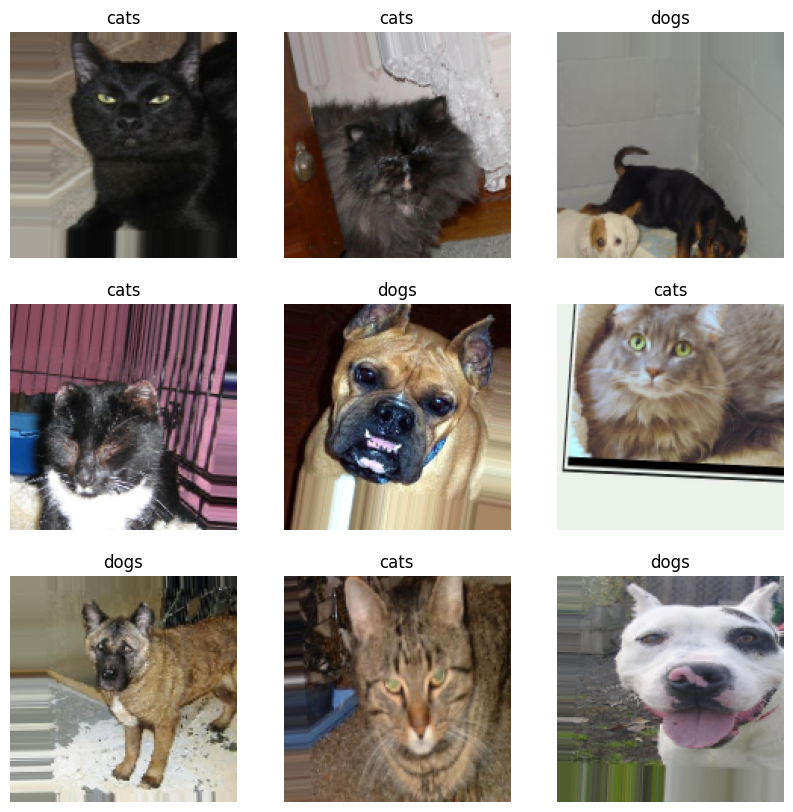

In [7]:
# CELL 7  Visualize sample images
images, labels = next(train_generator)
class_names = ['cats', 'dogs']

plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    plt.title(class_names[int(labels[i])])
    plt.axis('off')
plt.show()

In [8]:
# CELL 8 Build or load model
model_path = '/content/drive/MyDrive/cats-dogs-project/model.keras'

if os.path.exists(model_path):
    model = load_model(model_path)
    print("Model loaded from Drive — skipping training!")
    model_loaded = True
else:
    print("No saved model found — building from scratch...")
    model_loaded = False

    model = models.Sequential([
        layers.Input(shape=(150, 150, 3)),

        # Block 1 — finds basic features like edges and corners
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 2 — finds more complex features like eyes and ears
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Block 3 — finds high level features like faces and tails
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D(2, 2),

        # Flatten and classify
        layers.Flatten(),
        layers.Dense(512, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(1, activation='sigmoid')  # 0 = cat, 1 = dog
    ])

    model.summary()

Model loaded from Drive — skipping training!


In [9]:
# CELL 9 Compile and train (skips if model was loaded)
if not model_loaded:
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_generator,
        epochs=20,
        validation_data=val_generator
    )

    # Save model to Drive so you never retrain again
    model.save(model_path)
    print("Model saved to Drive!")

In [10]:
# CELL 10 Plot training history (only if we just trained)
if not model_loaded:
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc,     'b', label='Training accuracy')
    plt.plot(epochs, val_acc, 'r', label='Validation accuracy')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss,     'b', label='Training loss')
    plt.plot(epochs, val_loss, 'r', label='Validation loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

In [11]:
# Cell 11  Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"\nTest Accuracy: {test_acc * 100:.2f}%")
print(f"Test Loss:     {test_loss:.4f}")

13/79 ━━━━━━━━━━━━━━━━━━━━ 4s 70ms/step - accuracy: 0.9076 - loss: 0.2556

/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


79/79 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.8944 - loss: 0.2610

Test Accuracy: 89.44%
Test Loss:     0.2610


In [12]:
pip install gradio

In [13]:
# Cell 12 building interface
# Load saved model from Drive
model = load_model('/content/drive/MyDrive/cats-dogs-project/model.keras')

def predict(img):
    # Resize and normalize the uploaded image
    img = img.resize((150, 150))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Make prediction
    prediction = model.predict(img_array)[0][0]

    if prediction > 0.5:
        label = "Dog"
        confidence = prediction
    else:
        label = "Cat"
        confidence = 1 - prediction

    return f"{label} ({confidence * 100:.2f}% confidence)"

# Build the interface
app = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=gr.Text(label="Prediction"),
    title="Cats vs Dogs Classifier",
    description="Upload any image of a cat or dog and the model will identify it."
)

app.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://84703a0f43c68a9a00.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
